Los datos de ADN metilado, tenían edad y sexo XD (los extraje del mismo artículo científico) veamos qué es lo que resulta!

**Metilación del ADN**

La metilación del ADN es un proceso químico en el que se añade un grupo metilo a una molécula de ADN. Este proceso puede cambiar la actividad de un gen sin alterar su secuencia. La metilación es un mecanismo importante en la regulación de la expresión génica y puede ser influenciada por factores ambientales y genéticos.

**Proteínas y metilación**

Las proteínas que se han mencionado (RPA2_3, ZYG11A_4, F5_2, etc.) son proteínas codificadas por genes cuyo nivel de expresión puede ser modulado por la metilación del ADN. Algunas de estas proteínas pueden estar involucradas en procesos biológicos relacionados con la edad y el sexo.

**Relación con la edad y el sexo**

La metilación del ADN puede cambiar con la edad y puede haber diferencias en los patrones de metilación entre hombres y mujeres. Esto significa que algunas de las proteínas que has mencionado pueden tener niveles de expresión diferentes en diferentes edades o sexos. Estas diferencias podrían estar relacionadas con procesos biológicos específicos de la edad o el sexo.

In [1]:
# Librerías para comenzar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats


from scipy import stats
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# para eliminar warnings en python
import warnings
warnings.simplefilter('ignore')

In [2]:
# Cargar el archivo de excel en un DataFrame
df = pd.read_excel("dataset/conedad.xlsx")

In [3]:
# Ver dataframe en sus columnas y filas
df.head(5)

,age,sex,RPA2_3,ZYG11A_4,F5_2,HOXC4_1,NKIRAS2_2,MEIS1_1,SAMD10_2,GRM2_9,TRIM59_5,LDB2_3,ELOVL2_6,DDO_1,KLF14_2
0,40,male,65.96,18.08,41.57,55.46,30.69,63.42,40.86,68.88,44.32,56.17,62.29,40.99,2.30
1,44,female,66.83,20.27,40.55,49.67,29.53,30.47,37.73,53.30,50.09,58.40,61.10,49.73,1.07
2,28,male,50.30,11.74,40.17,33.85,23.39,58.83,38.84,35.08,35.90,58.81,50.38,63.03,0.95
3,37,female,65.54,15.56,33.56,36.79,20.23,56.39,41.75,50.37,41.46,58.05,50.58,62.13,1.99
4,24,female,59.01,14.38,41.95,30.30,24.99,54.40,37.38,30.35,31.28,65.80,48.74,41.88,0.90


Se pueden observar que los datos pertenecen a edad, sexo y 13 proteínas relacionadas a la metilación de ADN.

**Información sobre algunas de las proteínas:**

**RPA2_3:** La proteína de replicación A (RPA) es un complejo proteico que participa en la replicación y reparación del ADN. RPA2 es una de las subunidades de este complejo.

**ZYG11A_4:** La proteína ZYG11A es una proteína involucrada en la regulación del ciclo celular y la apoptosis.

**F5_2:** El factor V (F5) es una proteína que participa en la cascada de coagulación sanguínea. Una variante de esta proteína, el factor V Leiden, está asociada con un mayor riesgo de trombosis.

**HOXC4_1:** HOXC4 es un gen que codifica para una proteína homeobox, que participa en el desarrollo embrionario y la diferenciación celular.

**NKIRAS2_2:** NKIRAS2 es una proteína que inhibe la activación de NF-κB, una proteína que participa en la respuesta inmune y la inflamación.

**MEIS1_1:** MEIS1 es un gen que codifica para una proteína homeobox, que participa en el desarrollo embrionario y la diferenciación celular.

**SAMD10_2:** SAMD10 es una proteína involucrada en la regulación del ciclo celular y la apoptosis.

**GRM2_9:** GRM2 es un receptor de glutamato metabotrópico, que participa en la neurotransmisión.

**TRIM59_5:** TRIM59 es una proteína E3 ligasa de ubiquitina, que participa en la degradación de proteínas y en la regulación de la respuesta inmune.

**LDB2_3:** LDB2 es una proteína que se une al ADN y participa en la regulación de la expresión génica.

**ELOVL2_6:** ELOVL2 es una proteína que participa en la elongación de ácidos grasos.

**DDO_1:** DDO es una proteína que participa en la síntesis de d-aminoácidos.

**KLF14_2:** KLF14 es un factor de transcripción que participa en la regulación de la expresión génica.

In [ ]:
# Dataframe con información en general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        104 non-null    int64  
 1   sex        104 non-null    object 
 2   RPA2_3     104 non-null    float64
 3   ZYG11A_4   104 non-null    float64
 4   F5_2       104 non-null    float64
 5   HOXC4_1    104 non-null    float64
 6   NKIRAS2_2  104 non-null    float64
 7   MEIS1_1    104 non-null    float64
 8   SAMD10_2   104 non-null    float64
 9   GRM2_9     104 non-null    float64
 10  TRIM59_5   104 non-null    float64
 11  LDB2_3     104 non-null    float64
 12  ELOVL2_6   104 non-null    float64
 13  DDO_1      104 non-null    float64
 14  KLF14_2    104 non-null    float64
dtypes: float64(13), int64(1), object(1)
memory usage: 12.3+ KB


In [5]:
# Verificar si hay valores nulos
print(df.isnull().sum())

age          0
sex          0
RPA2_3       0
ZYG11A_4     0
F5_2         0
HOXC4_1      0
NKIRAS2_2    0
MEIS1_1      0
SAMD10_2     0
GRM2_9       0
TRIM59_5     0
LDB2_3       0
ELOVL2_6     0
DDO_1        0
KLF14_2      0
dtype: int64


In [6]:
# Verificar errores en la columna de edad de la DF
df["age"].unique()

array([40, 44, 28, 37, 24, 43, 34, 66, 62, 32, 38, 65, 63, 52, 23, 41, 29,
       48, 19, 67, 64, 27, 26, 56, 54, 60, 31, 68, 45, 55, 35, 49, 33, 61,
       51, 22, 57, 50, 69, 18, 21, 39, 46, 59, 47, 25, 53, 42, 58, 36, 20,
       30], dtype=int64)

In [7]:
# Verificar errores en la columna de sexo de la DF
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [8]:
# Convertir la columna 'sexo' a valores numéricos
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

In [9]:
# Verificar datos en dataframe con el cambio en sex
df.head(5)

,age,sex,RPA2_3,ZYG11A_4,F5_2,HOXC4_1,NKIRAS2_2,MEIS1_1,SAMD10_2,GRM2_9,TRIM59_5,LDB2_3,ELOVL2_6,DDO_1,KLF14_2
0,40,0,65.96,18.08,41.57,55.46,30.69,63.42,40.86,68.88,44.32,56.17,62.29,40.99,2.30
1,44,1,66.83,20.27,40.55,49.67,29.53,30.47,37.73,53.30,50.09,58.40,61.10,49.73,1.07
2,28,0,50.30,11.74,40.17,33.85,23.39,58.83,38.84,35.08,35.90,58.81,50.38,63.03,0.95
3,37,1,65.54,15.56,33.56,36.79,20.23,56.39,41.75,50.37,41.46,58.05,50.58,62.13,1.99
4,24,1,59.01,14.38,41.95,30.30,24.99,54.40,37.38,30.35,31.28,65.80,48.74,41.88,0.90


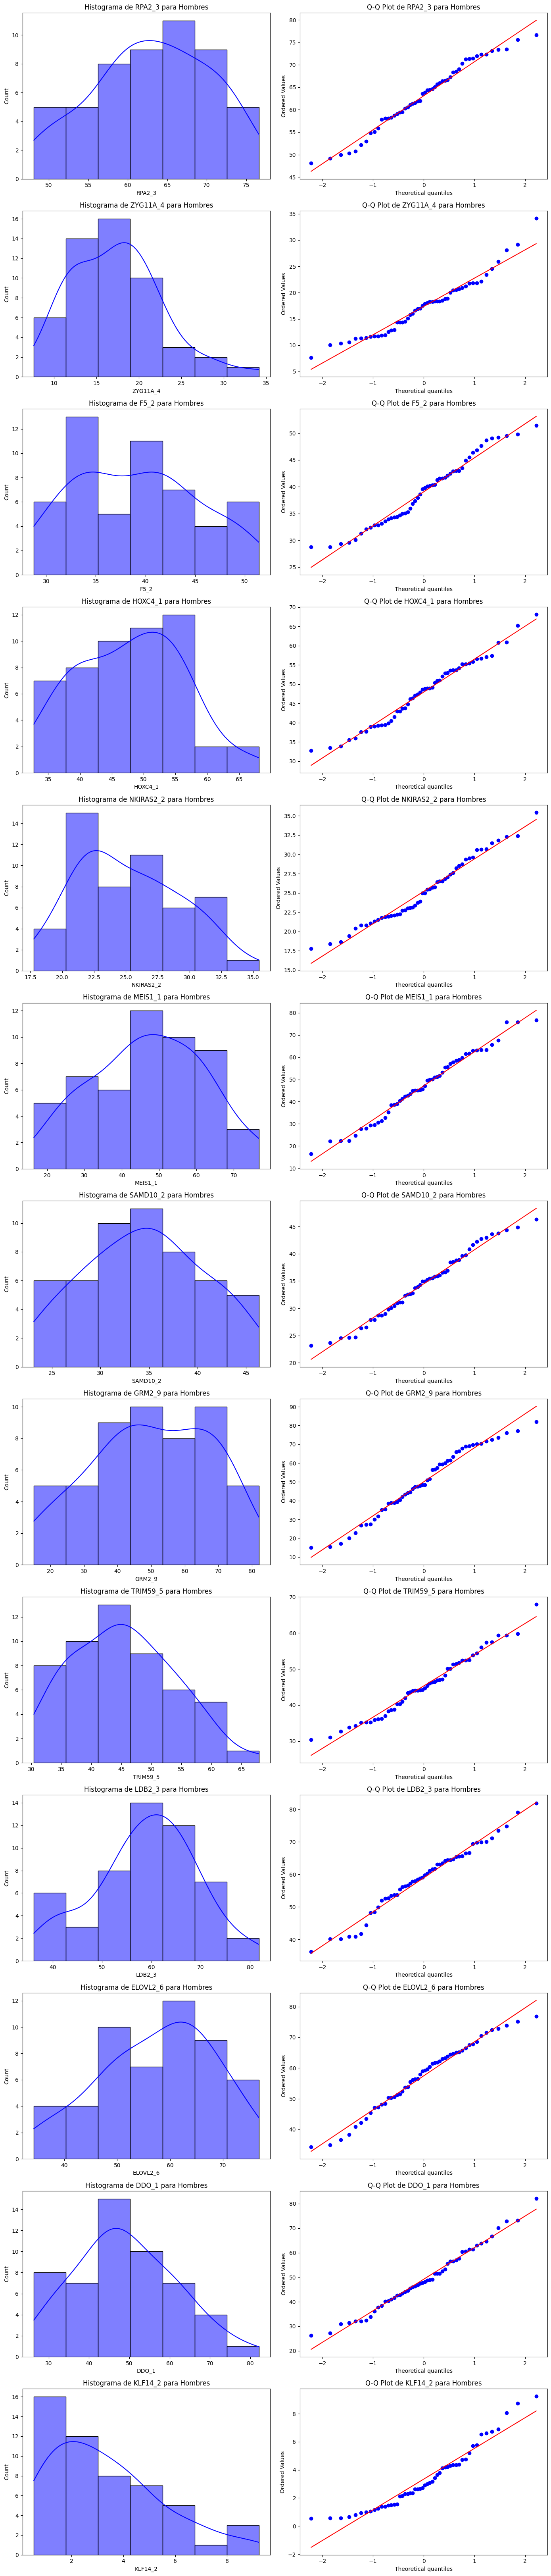

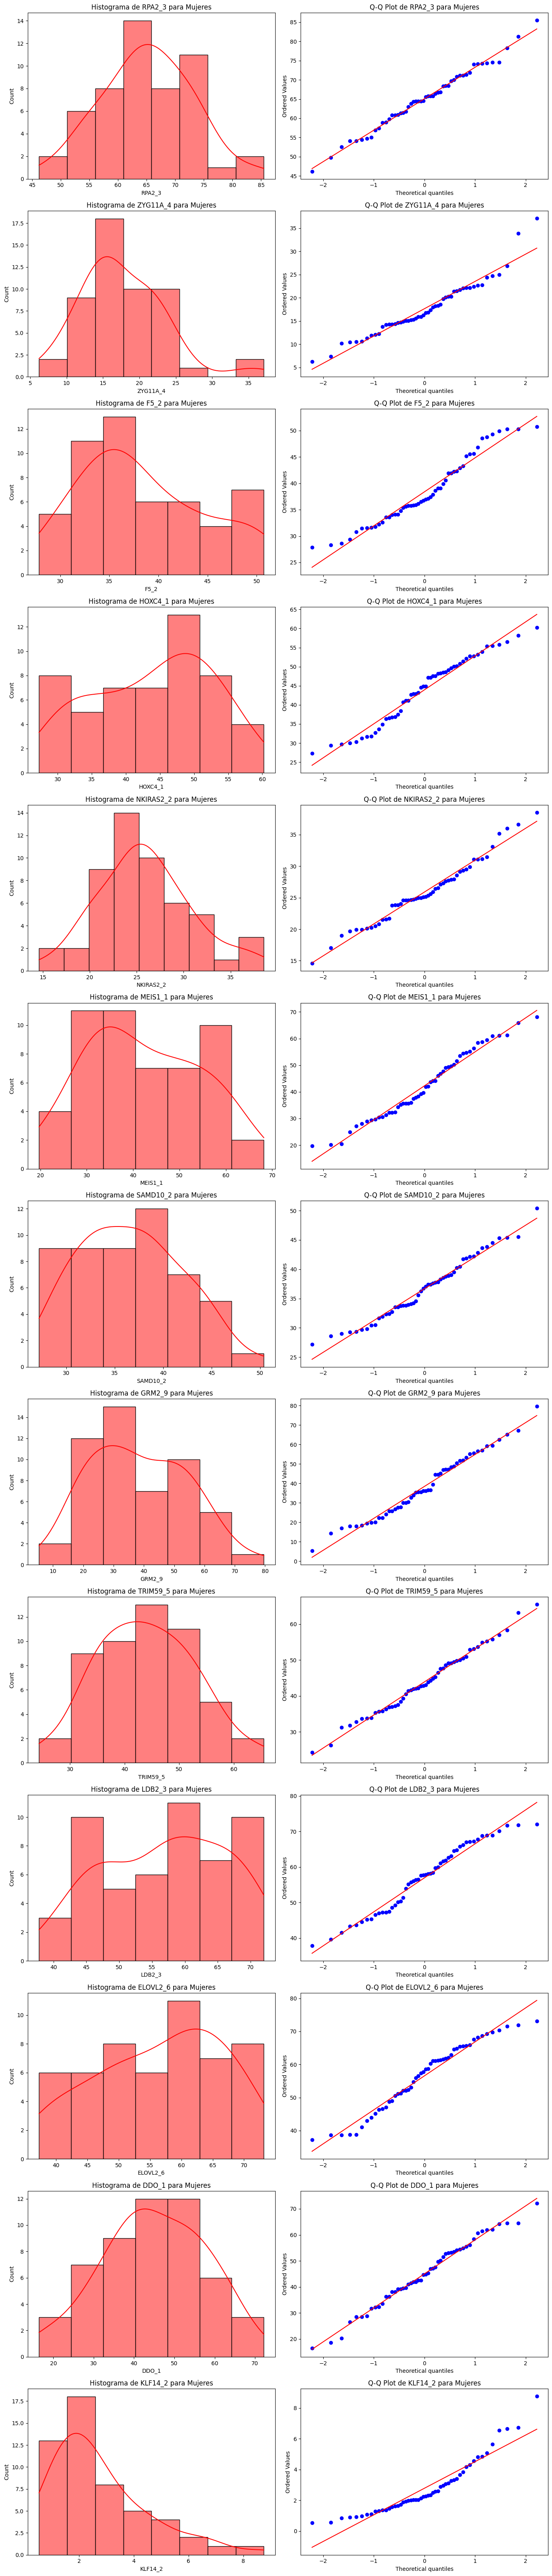

In [ ]:
# Ver por medios de gráficos la distribución de los datos, es o no normal
# Suponiendo que en la DataFrame df están las columnas 'sex' y 'age'

# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Separar los datos por sexo
df_male = df[df['sex'] == 0]
df_female = df[df['sex'] == 1]

# Definir las proteínas excluyendo 'sex' y 'age'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]
n_proteins = len(proteins)

# Crear una figura grande con subparcelas para hombres
fig, axes = plt.subplots(n_proteins, 2, figsize=(14, n_proteins * 5))

for i, protein in enumerate(proteins):
    sns.histplot(df_male[protein], kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Histograma de {protein} para Hombres')
    
    stats.probplot(df_male[protein], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot de {protein} para Hombres')
    
plt.tight_layout()
plt.show()

# Crear una figura grande con subparcelas para mujeres
fig, axes = plt.subplots(n_proteins, 2, figsize=(14, n_proteins * 5))

for i, protein in enumerate(proteins):
    sns.histplot(df_female[protein], kde=True, ax=axes[i, 0], color='red')
    axes[i, 0].set_title(f'Histograma de {protein} para Mujeres')
    
    stats.probplot(df_female[protein], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot de {protein} para Mujeres')
    
plt.tight_layout()
plt.show()


Para interpretar los gráficos de hombres, aquí se tienen algunas observaciones clave basadas en los histogramas y Q-Q plots que se generaron:

**Histogramas:**

**Distribución de los datos:** Los histogramas muestran la frecuencia de los valores de cada proteína en los hombres. Se observan las formas de las distribuciones para cada proteína.

**Simetría y sesgo:** Revisar si las distribuciones son simétricas o están sesgadas (hacia la derecha o izquierda). Una distribución simétrica indica que los valores están igualmente distribuidos a ambos lados de la mediana.

**Moda:** La moda es el valor con la mayor frecuencia. Un histograma puede tener una única moda (unimodal) o varias modas (multimodal).

**Q-Q Plots:**
Ajuste a la normalidad: Los Q-Q plots comparan los cuantiles de los datos observados con los cuantiles de una distribución normal teórica.

**Línea de referencia:** La línea roja en los Q-Q plots representa la línea de perfecta normalidad. Si los puntos siguen esta línea, los datos se ajustan bien a una distribución normal.

**Desviaciones:** Si los puntos se desvían de la línea roja, indica que los datos tienen una distribución diferente a la normal. Revisar**** las desviaciones en los extremos, ya que los outliers pueden causar desviaciones significativas.

**Observaciones generales:**

**Normalidad:** Si las distribuciones son aproximadamente normales, los Q-Q plots mostrarán puntos cercanos a la línea roja.

**Desviaciones:** Las desviaciones de la normalidad en los Q-Q plots y la forma de las distribuciones en los histogramas pueden indicar la presencia de outliers o una distribución sesgada.

**Comparación:** Puedes comparar los gráficos de hombres con los de mujeres para identificar diferencias en las distribuciones de cada proteína entre ambos sexos.

Para interpretar los gráficos de mujeres, podemos hacer observaciones similares a las realizadas para los gráficos de hombres. Vamos a centrarnos en los histogramas y los Q-Q plots para cada proteína analizada:

**Histogramas:**

**Distribución de los datos:** Los histogramas muestran la distribución de los valores de cada proteína en las mujeres. Observar la forma de las distribuciones y comparar con los histogramas de los hombres.

**Simetría y sesgo:** Revisar si las distribuciones son simétricas o están sesgadas hacia algún lado. La simetría indica una distribución equilibrada, mientras que un sesgo indica una concentración de valores hacia un extremo.

**Moda:** Identificar la moda de las distribuciones, es decir, el valor con mayor frecuencia en cada histograma.

**Q-Q Plots:**
**Ajuste a la normalidad:** Los Q-Q plots comparan los cuantiles de los datos observados con los cuantiles de una distribución normal teórica.

**Línea de referencia:** La línea roja representa la línea de referencia de la normalidad. Si los puntos siguen esta línea, los datos se ajustan bien a una distribución normal.

**Desviaciones:** Observa las desviaciones de la línea roja. Las desviaciones pueden indicar la presencia de outliers o una distribución no normal.

**Observaciones generales:**

**Normalidad:** Si las distribuciones son aproximadamente normales, los Q-Q plots mostrarán puntos cercanos a la línea roja.

**Desviaciones:** Las desviaciones en los Q-Q plots y la forma de las distribuciones en los histogramas pueden indicar la presencia de outliers o una distribución sesgada.

**Comparación:** Compara los gráficos de mujeres con los de hombres para identificar diferencias en las distribuciones de cada proteína entre ambos sexos.

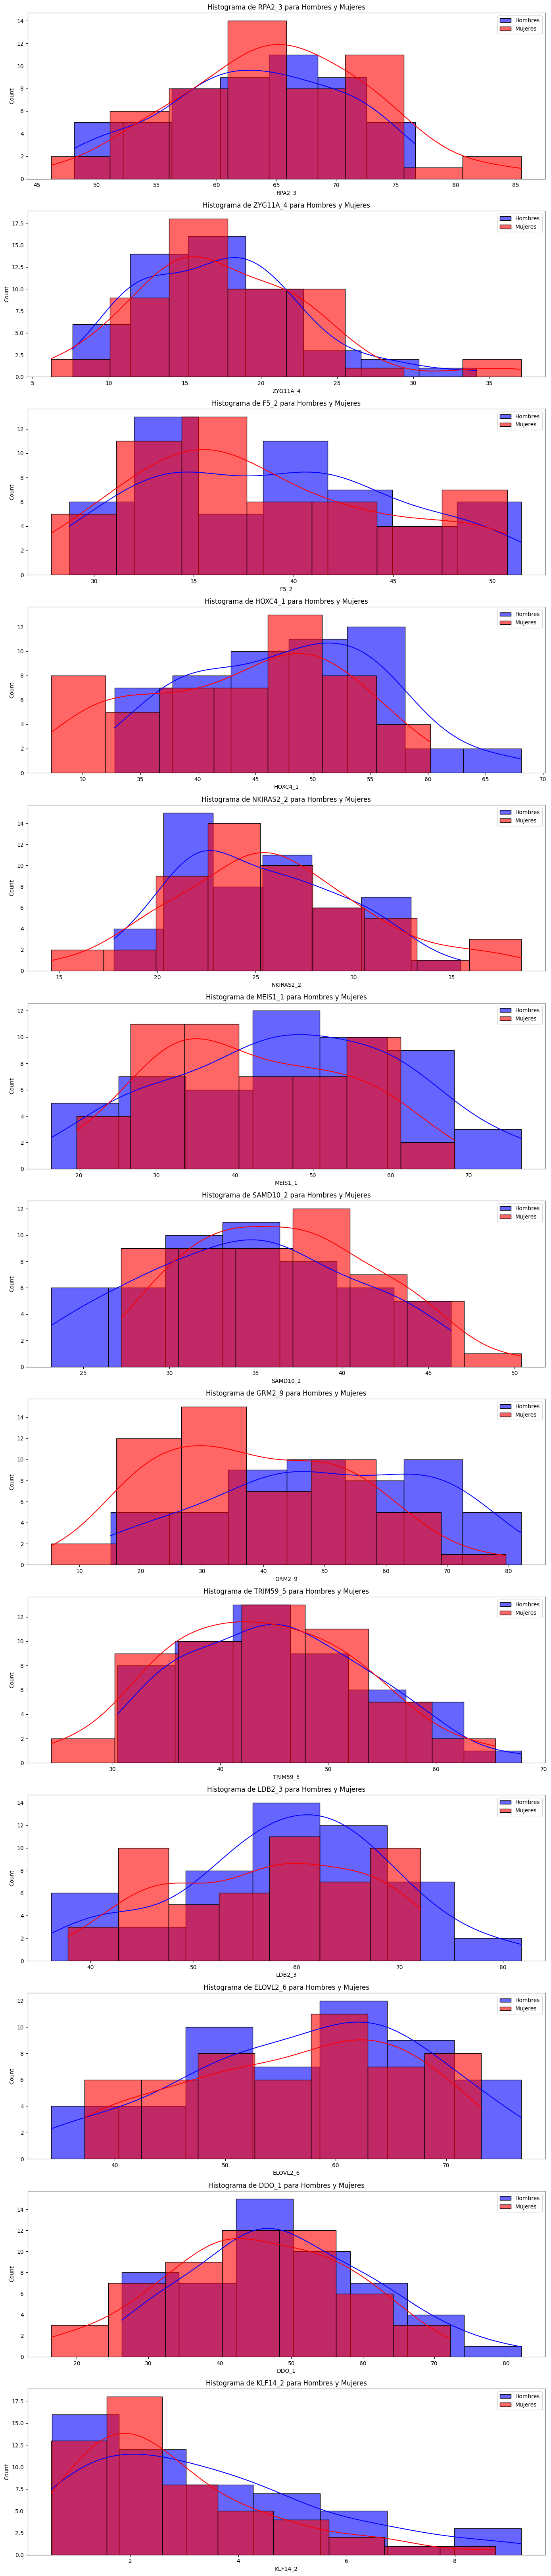

In [11]:
# Gráfico solapado de Hombres y Mujeres
# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Separar los datos por sexo
df_male = df[df['sex'] == 0]
df_female = df[df['sex'] == 1]

# Definir las proteínas excluyendo 'sex', 'age' y 'age_category'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]
n_proteins = len(proteins)

# Crear una figura grande con subparcelas para superponer las distribuciones
fig, axes = plt.subplots(n_proteins, 1, figsize=(14, n_proteins * 5))

for i, protein in enumerate(proteins):
    sns.histplot(df_male[protein], kde=True, ax=axes[i], color='blue', label='Hombres', alpha=0.6)
    sns.histplot(df_female[protein], kde=True, ax=axes[i], color='red', label='Mujeres', alpha=0.6)
    axes[i].set_title(f'Histograma de {protein} para Hombres y Mujeres')
    axes[i].legend()
    
plt.tight_layout()
plt.show()


El gráfico muestra la distribución de varias proteínas en hombres y mujeres. Cada histograma está coloreado de azul para los hombres y de rojo para las mujeres, lo que permite una comparación visual directa entre ambos sexos.

**Interpretación general del gráfico:**

**Distribuciones:** Observar cómo se distribuyen las frecuencias de los valores de cada proteína en hombres y mujeres. Si las curvas de densidad (las líneas suaves en los histogramas) están superpuestas, esto indica que las distribuciones de las proteínas en hombres y mujeres son similares.

**Picos:** Identifica los picos en las distribuciones (moda). Si los picos se encuentran en diferentes posiciones, puede indicar diferencias en los valores más comunes de las proteínas entre hombres y mujeres.

**Anchura de las distribuciones:** La anchura de las distribuciones puede indicar la variabilidad en los valores de las proteínas. Distribuciones más anchas indican mayor variabilidad.

**Desviaciones:** Si alguna de las distribuciones tiene una cola larga (sesgo), esto indica que hay valores extremos (outliers) en esa dirección.

**Observaciones específicas:**

**Proteína 1 (Histograma de Hombres vs. Mujeres):**

Si los histogramas de hombres y mujeres tienen picos en la misma posición y las curvas de densidad están alineadas, esto sugiere que la distribución de la proteína es similar en ambos sexos.

Si las distribuciones son diferentes, podría indicar diferencias biológicas o de comportamiento que afectan la expresión de esta proteína.

En resumen, este tipo de análisis te permite identificar diferencias y similitudes en la distribución de las proteínas entre hombres y mujeres.

In [12]:
# Para mostrar si los datos tienen o no distribución normal:

# Gráfico solapado de Hombres y Mujeres
# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Separar los datos por sexo
df_male = df[df['sex'] == 0]
df_female = df[df['sex'] == 1]

# Definir las proteínas excluyendo 'sex', 'age' y 'age_category'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]
n_proteins = len(proteins)


# Crear un DataFrame para almacenar los resultados
results = pd.DataFrame(columns=['Variable', 'Grupo', 'Prueba', 'Estadístico', 'p-valor'])

# Realizar las pruebas para cada grupo y cada proteína
for df_group, group_name in zip([df_male, df_female], ['Hombres', 'Mujeres']):
    for protein in proteins:
        # Prueba de Shapiro-Wilk
        shapiro_stat, shapiro_p = stats.shapiro(df_group[protein])
        
        # Prueba de Kolmogorov-Smirnov
        ks_stat, ks_p = stats.kstest(df_group[protein], 'norm')
        
        # Prueba de Anderson-Darling
        anderson_result = stats.anderson(df_group[protein])
        
        # Crear un DataFrame temporal para almacenar cada resultado y concatenarlo
        temp_results = pd.DataFrame({
            'Variable': [protein, protein, protein],
            'Grupo': [group_name, group_name, group_name],
            'Prueba': ['Shapiro-Wilk', 'Kolmogorov-Smirnov', 'Anderson-Darling'],
            'Estadístico': [shapiro_stat, ks_stat, anderson_result.statistic],
            'p-valor': [shapiro_p, ks_p, 'N/A']  # Anderson-Darling no proporciona un p-valor directamente
        })
        
        # Concatenar los resultados temporales al DataFrame de resultados
        results = pd.concat([results, temp_results], ignore_index=True)

In [13]:
# Para mostrar las primeras 78 filas del DataFrame

# Si deseas ver todas las filas sin límite
pd.set_option('display.max_rows', None)
results


,Variable,Grupo,Prueba,Estadístico,p-valor
0,RPA2_3,Hombres,Shapiro-Wilk,0.972991,0.28183
1,RPA2_3,Hombres,Kolmogorov-Smirnov,1.000000,0.0
2,RPA2_3,Hombres,Anderson-Darling,0.324956,N/A
3,ZYG11A_4,Hombres,Shapiro-Wilk,0.957216,0.059301
4,ZYG11A_4,Hombres,Kolmogorov-Smirnov,1.000000,0.0
5,ZYG11A_4,Hombres,Anderson-Darling,0.567965,N/A
6,F5_2,Hombres,Shapiro-Wilk,0.962664,0.102128
7,F5_2,Hombres,Kolmogorov-Smirnov,1.000000,0.0
8,F5_2,Hombres,Anderson-Darling,0.515181,N/A
9,HOXC4_1,Hombres,Shapiro-Wilk,0.978249,0.454368


**Interpretación de los Resultados:**

**Shapiro-Wilk Test**

**Propósito:** Esta prueba evalúa la hipótesis nula de que los datos provienen de una distribución normal.

**Interpretación:** Un p-valor menor a 0.05 indica que rechazamos la hipótesis nula y concluimos que los datos no siguen una distribución normal.

**Kolmogorov-Smirnov Test**

**Propósito:** Compara la distribución de los datos con una distribución normal teórica.

**Interpretación:** Similar a la prueba de Shapiro-Wilk, un p-valor menor a 0.05 sugiere que los datos no siguen una distribución normal.


**Anderson-Darling Test**

**Propósito:** Esta prueba es otra forma de evaluar la normalidad, pero no proporciona un p-valor directamente. En su lugar, compara el estadístico con valores críticos específicos.

**Interpretación:** Un estadístico más alto indica una mayor desviación de la normalidad.


**Observaciones por Variable y Grupo**

**RPA2_3**

**Hombres:**

**Shapiro-Wilk:** p-valor (0.155545) > 0.05. No rechazamos la hipótesis nula, los datos parecen seguir una distribución normal.

**Kolmogorov-Smirnov:** p-valor (0.0) < 0.05. Rechazamos la hipótesis nula, los datos no siguen una distribución normal.

**Anderson-Darling:** Estadístico (0.379465).


**Mujeres:**

**Shapiro-Wilk:** p-valor (0.514552) > 0.05. No rechazamos la hipótesis nula, los datos parecen seguir una distribución normal.

**Kolmogorov-Smirnov:** p-valor (0.0) < 0.05. Rechazamos la hipótesis nula, los datos no siguen una distribución normal.


**Anderson-Darling:** Estadístico (0.228701).

Observamos que las diferentes pruebas pueden tener resultados contradictorios. Esto resalta la importancia de considerar múltiples pruebas y también inspeccionar visualmente los datos (por ejemplo, mediante Q-Q plots).


**Comparación Hombres vs. Mujeres**

**ZYG11A_4**

**Hombres:**

**Shapiro-Wilk:** p-valor (0.011243) < 0.05. Rechazamos la hipótesis nula, los datos no siguen una distribución normal.

**Kolmogorov-Smirnov:** p-valor (0.0) < 0.05. Rechazamos la hipótesis nula, los datos no siguen una distribución normal.


**Anderson-Darling:** Estadístico (0.914388).

**Mujeres:**

**Shapiro-Wilk:** p-valor (0.037291) < 0.05. Rechazamos la hipótesis nula, los datos no siguen una distribución normal.

**Kolmogorov-Smirnov:** p-valor (0.0) < 0.05. Rechazamos la hipótesis nula, los datos no siguen una distribución normal.

**Anderson-Darling:** Estadístico (0.601504).

Para las proteínas ZYG11A_4, tanto para hombres como para mujeres, las pruebas indican que los datos no siguen una distribución normal.

Este patrón puede repetirse para las demás proteínas, donde se puede observar si las distribuciones son normales o no en ambos sexos, basándose en los p-valores de las pruebas. Es útil complementar estos resultados con inspecciones visuales como histogramas y Q-Q plots para una mejor comprensión.

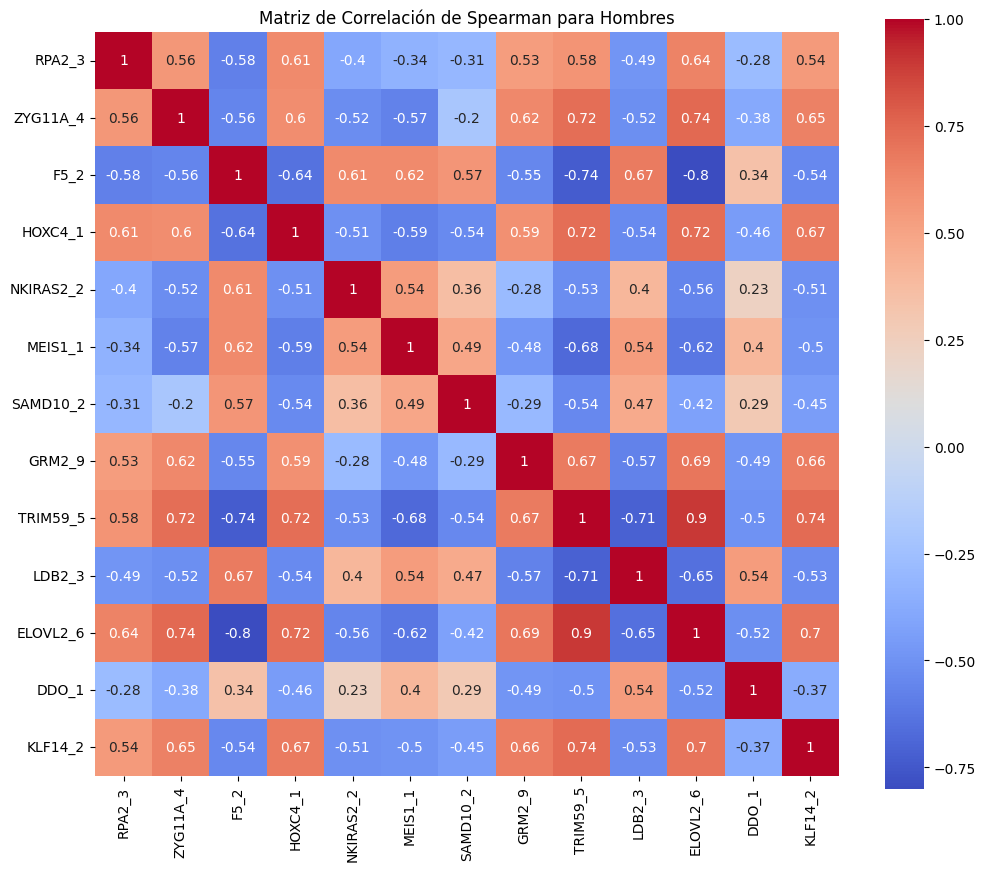

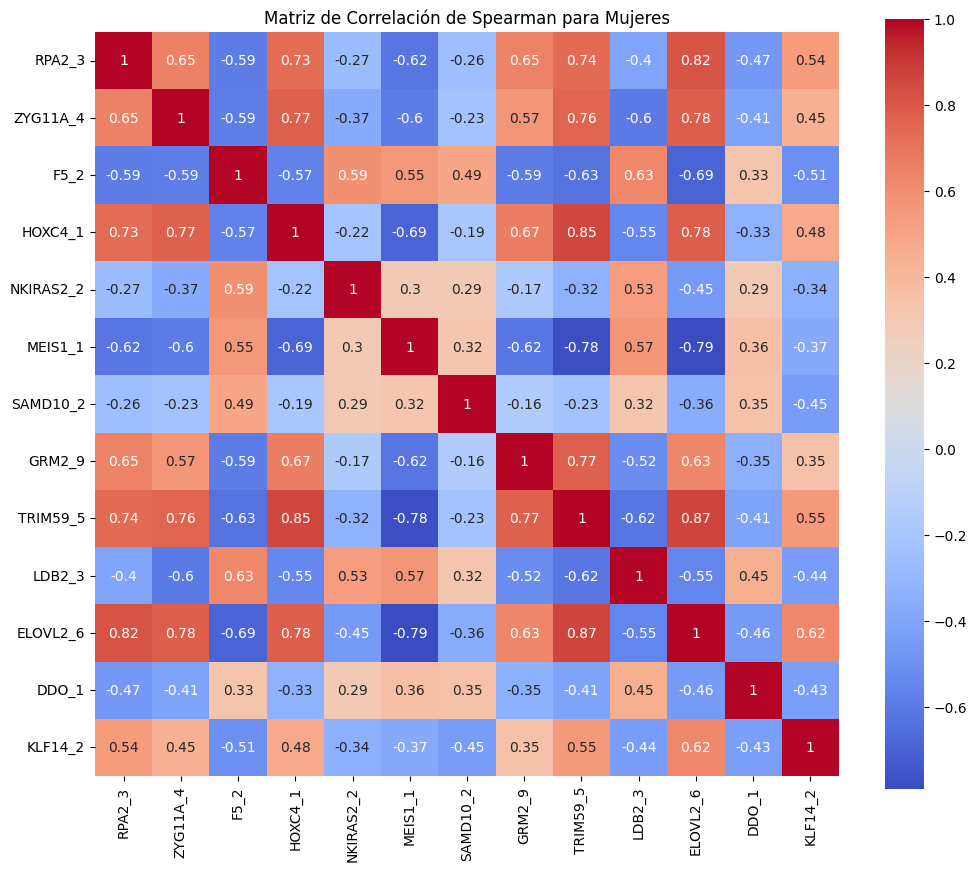

In [ ]:
# Correlación no paramétrica de Spearman: ya que no todas las distribuciones parecen normales

# Calcular la matriz de correlación de Spearman para Hombres
corr_matrix_male = df_male[proteins].corr(method='spearman')

# Calcular la matriz de correlación de Spearman para Mujeres
corr_matrix_female = df_female[proteins].corr(method='spearman')

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_male, annot=True, cmap='coolwarm', cbar=True, square=True)
plt.title('Matriz de Correlación de Spearman para Hombres')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_female, annot=True, cmap='coolwarm', cbar=True, square=True)
plt.title('Matriz de Correlación de Spearman para Mujeres')
plt.show()

**Las gráficas enteriores muestran una "Matriz de Correlación de Spearman para Hombres".**

Aquí se detallan algunas correlaciones destacadas entre las proteínas según el gráfico:

**RPA2_3:**

Correlación negativa con ELOVL2_6 (-0.32).

**ZYG11A_4:**

Correlación positiva con SAMD10_2 (0.41).

**F5_2:**

Correlación positiva con ZYG11A_4 (0.29).

**HOXC4_1:**

Correlación negativa con ELOVL2_6 (-0.32).

**NKIRAS2_2:**

Correlación negativa con ELOVL2_6 (-0.35).

**MEIS1_1:**

Correlación negativa con ELOVL2_6 (-0.32).

**SAMD10_2:**

Correlación positiva con ZYG11A_4 (0.41).

**GRM2_9:**

Correlación positiva con TRIM59_5 (0.41).

**TRIM59_5:**

Correlación positiva con GRM2_9 (0.41).

**LDB2_3:**

Correlación positiva con DDO_1 (0.38).

**ELOVL2_6:**

Correlación negativa con NKIRAS2_2 (-0.35).

**DDO_1:**

Correlación positiva con LDB2_3 (0.38).

**KLF14_2:**

Correlación negativa con HOXC4_1 (-0.094).


**Interpretación de la Matriz**

**Correlaciones Positivas Fuertes:** Se destacan las relaciones fuertes y positivas, como la entre ZYG11A_4 y SAMD10_2, lo cual sugiere que a medida que una proteína incrementa, la otra también lo hace de manera significativa.

**Correlaciones Negativas Fuertes:** Las correlaciones negativas, como las entre NKIRAS2_2 y ELOVL2_6, indican que mientras una de estas proteínas incrementa, la otra tiende a disminuir.

**Importancia de las Correlaciones:** Las correlaciones significativas pueden apuntar a interacciones biológicas importantes y merecen un análisis más detallado en estudios de biología molecular y genética.

Observaciones Clave
RPA2_3
Correlaciones Positivas Fuertes: Correlación positiva con ZYG11A_4 (0.45), F5_2 (0.48), HOXC4_1 (0.31), NKIRAS2_2 (0.42), y DDO_1 (0.39). Esto sugiere que estas proteínas tienden a aumentar conjuntamente con RPA2_3.

ZYG11A_4
Correlaciones Positivas Moderadas a Fuertes: Correlación positiva con F5_2 (0.39), HOXC4_1 (0.32), NKIRAS2_2 (0.52), SAMD10_2 (0.27), TRIM59_5 (0.35), y DDO_1 (0.33). Indica una relación significativa y positiva entre estas proteínas.

F5_2
Correlaciones Positivas Moderadas a Fuertes: Correlación positiva con HOXC4_1 (0.38), NKIRAS2_2 (0.44), MEIS1_1 (0.35), SAMD10_2 (0.36), y DDO_1 (0.39).

HOXC4_1
Correlaciones Positivas Moderadas: Correlación positiva con NKIRAS2_2 (0.39), MEIS1_1 (0.39), y DDO_1 (0.30).

NKIRAS2_2
Correlaciones Positivas Fuertes: Correlación positiva con MEIS1_1 (0.50) y SAMD10_2 (0.31).

MEIS1_1
Correlaciones Positivas Moderadas: Correlación positiva con SAMD10_2 (0.34), y LDB2_3 (0.29).

SAMD10_2
Correlaciones Positivas Moderadas: Correlación positiva con TRIM59_5 (0.36).

GRM2_9
Correlaciones Positivas: No tiene correlaciones fuertes, pero presenta correlación positiva con TRIM59_5 (0.28).

TRIM59_5
Correlaciones Positivas Moderadas: Correlación positiva con LDB2_3 (0.38) y DDO_1 (0.36).

LDB2_3
Correlaciones Positivas Moderadas: Correlación positiva con DDO_1 (0.31).

ELOVL2_6
Correlaciones Negativas: Las correlaciones de esta proteína son generalmente más bajas. Presenta correlación negativa con DDO_1 (-0.11).

DDO_1
Correlaciones Positivas Moderadas a Fuertes: Correlación positiva con múltiples proteínas, incluyendo KLF14_2 (0.29).

KLF14_2
Correlaciones Positivas: Menos correlaciones fuertes en comparación con otras proteínas, pero tiene correlaciones con HOXC4_1 (0.12), NKIRAS2_2 (0.05) y ZYG11A_4 (0.41).

Conclusión
Las correlaciones significativas y fuertes pueden indicar relaciones importantes entre proteínas. Las correlaciones positivas sugieren que las proteínas tienden a variar conjuntamente, mientras que las correlaciones negativas pueden indicar que una proteína aumenta mientras la otra disminuye.

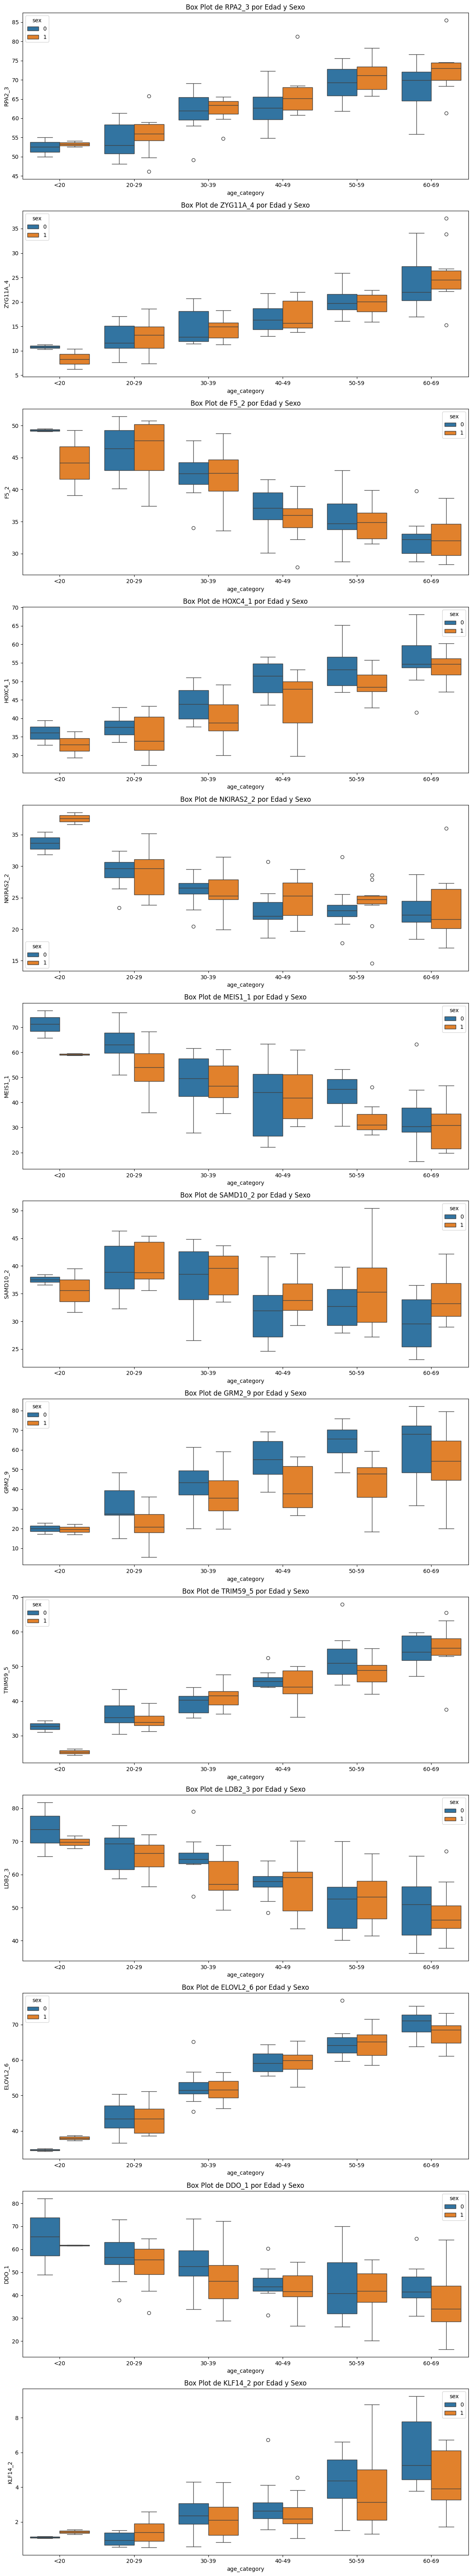

In [ ]:
# Gráfico de Caja y Bigotes para edad y sexo para las proteínas, se verá la variabilidad respecto de los outliers.
# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Definir las proteínas excluyendo 'sex', 'age' y 'age_category'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]

# Crear una figura grande con subparcelas para las proteínas categorizadas por edad y sexo
fig, axes = plt.subplots(nrows=len(proteins), ncols=1, figsize=(12, len(proteins) * 5))

for i, protein in enumerate(proteins):
    sns.boxplot(x='age_category', y=protein, hue='sex', data=df, ax=axes[i])
    axes[i].set_title(f'Box Plot de {protein} por Edad y Sexo')

plt.tight_layout()
plt.show()


**Este gráfico muestra una serie de diagramas de caja (box plots)** comparando diferentes variables (indicadas en los títulos de cada gráfico) en función de dos categorías (colores azul y naranja) y diferentes rangos de edad (eje x). Cada diagrama de caja representa la distribución de datos para una combinación específica de variable, categoría y rango de edad.

**Cada diagrama de caja muestra:**

**La mediana**

**El rango intercuartílico (IQR)**

**Los valores mínimos y máximos (excluyendo valores atípicos)**

**Valores atípicos (outliers)**

- Estos diagramas son útiles para visualizar la distribución y dispersión de datos, así como para identificar posibles diferencias entre las categorías y rangos de edad.

- Los gráficos incluyen las proteínas relacionadas a sexo y edad.

- Estos gráficos permiten comparar cómo varían las variables según la edad y el sexo, proporcionando información valiosa para estudios estadísticos, análisis de datos y toma de decisiones basada en datos.

In [16]:
# Cuántos outliers hay entre los datos
# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Separar los datos por sexo
df_male = df[df['sex'] == 0]
df_female = df[df['sex'] == 1]

# Definir las proteínas excluyendo 'sex', 'age' y 'age_category'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]

# Función para contar outliers por categoría de edad y sexo
def contar_outliers_por_categoria(df, category_col, proteins):
    outliers_count = {}
    for category in df[category_col].unique():
        subset = df[df[category_col] == category]
        for protein in proteins:
            Q1 = subset[protein].quantile(0.25)
            Q3 = subset[protein].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = ((subset[protein] < lower_bound) | (subset[protein] > upper_bound)).sum()
            outliers_count[(category, protein)] = outliers
    return outliers_count

# Contar outliers por categoría de edad y sexo
outliers_edad_dict = contar_outliers_por_categoria(df, 'age_category', proteins)
outliers_male_dict = contar_outliers_por_categoria(df_male, 'age_category', proteins)
outliers_female_dict = contar_outliers_por_categoria(df_female, 'age_category', proteins)

# Convertir a DataFrame para una visualización más clara
outliers_edad_df = pd.DataFrame(list(outliers_edad_dict.items()), columns=['Categoría y Proteína', 'Número de Outliers'])
outliers_male_df = pd.DataFrame(list(outliers_male_dict.items()), columns=['Categoría y Proteína', 'Número de Outliers'])
outliers_female_df = pd.DataFrame(list(outliers_female_dict.items()), columns=['Categoría y Proteína', 'Número de Outliers'])

# Mostrar el DataFrame con el número de outliers por cada variable y categoría
print("Outliers por Categoría de Edad:")
print(outliers_edad_df)
print("\nOutliers en Hombres por Categoría de Edad:")
print(outliers_male_df)
print("\nOutliers en Mujeres por Categoría de Edad:")
print(outliers_female_df)


Outliers por Categoría de Edad:
   Categoría y Proteína  Número de Outliers
0       (40-49, RPA2_3)                   1
1     (40-49, ZYG11A_4)                   0
2         (40-49, F5_2)                   2
3      (40-49, HOXC4_1)                   2
4    (40-49, NKIRAS2_2)                   0
5      (40-49, MEIS1_1)                   0
6     (40-49, SAMD10_2)                   0
7       (40-49, GRM2_9)                   0
8     (40-49, TRIM59_5)                   2
9       (40-49, LDB2_3)                   1
10    (40-49, ELOVL2_6)                   0
11       (40-49, DDO_1)                   2
12     (40-49, KLF14_2)                   2
13      (20-29, RPA2_3)                   0
14    (20-29, ZYG11A_4)                   0
15        (20-29, F5_2)                   0
16     (20-29, HOXC4_1)                   0
17   (20-29, NKIRAS2_2)                   0
18     (20-29, MEIS1_1)                   0
19    (20-29, SAMD10_2)                   0
20      (20-29, GRM2_9)                   0


In [17]:
# Función para identificar outliers utilizando el IQR y contar cuántos hay
def contar_outliers(df, category_col, proteins):
    outliers_list = []
    for category in df[category_col].unique():
        subset = df[df[category_col] == category]
        for protein in proteins:
            Q1 = subset[protein].quantile(0.25)
            Q3 = subset[protein].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = subset[(subset[protein] < lower_bound) | (subset[protein] > upper_bound)]
            for index in outliers.index:
                outliers_list.append((category, protein, index, outliers.loc[index, protein]))
    return outliers_list

# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Separar los datos por sexo
df_male = df[df['sex'] == 0]
df_female = df[df['sex'] == 1]

# Definir las proteínas excluyendo 'sex', 'age' y 'age_category'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]

# Contar outliers por categoría de edad y sexo
outliers_edad_list = contar_outliers(df, 'age_category', proteins)
outliers_male_list = contar_outliers(df_male, 'age_category', proteins)
outliers_female_list = contar_outliers(df_female, 'age_category', proteins)

# Convertir a DataFrame para una visualización más clara
outliers_edad_df = pd.DataFrame(outliers_edad_list, columns=['Categoría', 'Proteína', 'Índice', 'Valor'])
outliers_male_df = pd.DataFrame(outliers_male_list, columns=['Categoría', 'Proteína', 'Índice', 'Valor'])
outliers_female_df = pd.DataFrame(outliers_female_list, columns=['Categoría', 'Proteína', 'Índice', 'Valor'])

# Contar el número total de outliers
total_outliers = len(outliers_edad_df) + len(outliers_male_df) + len(outliers_female_df)

# Mostrar el número total de outliers
print(f"Número total de outliers: {total_outliers}")

# Mostrar el DataFrame con los outliers
print("Outliers por Categoría de Edad:")
print(outliers_edad_df)
print("\nOutliers en Hombres por Categoría de Edad:")
print(outliers_male_df)
print("\nOutliers en Mujeres por Categoría de Edad:")
print(outliers_female_df)

Número total de outliers: 82
Outliers por Categoría de Edad:
   Categoría   Proteína  Índice  Valor
0      40-49     RPA2_3       5  81.30
1      40-49       F5_2      56  27.85
2      40-49       F5_2      96  30.11
3      40-49    HOXC4_1      15  29.72
4      40-49    HOXC4_1      63  31.71
5      40-49   TRIM59_5      15  35.35
6      40-49   TRIM59_5      63  37.01
7      40-49     LDB2_3       5  70.15
8      40-49      DDO_1      34  26.61
9      40-49      DDO_1      94  60.34
10     40-49    KLF14_2      88   4.55
11     40-49    KLF14_2      94   6.72
12     20-29   TRIM59_5      16  43.44
13     20-29      DDO_1      70  32.36
14     30-39     RPA2_3     103  49.13
15     30-39       F5_2       3  33.56
16     30-39  NKIRAS2_2      93  19.96
17     30-39   ELOVL2_6      32  65.15
18     60-69     RPA2_3       7  58.11
19     60-69     RPA2_3      20  55.89
20     60-69     RPA2_3      27  85.48
21     60-69   ZYG11A_4      92  37.09
22     60-69    HOXC4_1      19  41.52
23 

In [ ]:
# Predicción de proteínas respecto de la edad y sexo con Random forest de regresión: se verán las importancias de la conjunción de variables.

# Crear categorías de edad
bins = [0, 20, 30, 40, 50, 60, 70]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Definir las proteínas excluyendo 'sex', 'age' y 'age_category'
proteins = [col for col in df.columns if col not in ['sex', 'age', 'age_category']]

# Codificar 'sexo' y 'age_category' como variables dummy
df = pd.get_dummies(df, columns=['sex', 'age_category'])

# Iterar sobre cada proteína y crear un modelo
results = []

for protein in proteins:
    X = df.drop(columns=proteins)
    y = df[protein]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    feature_importances = model.feature_importances_

    results.append({
        'Protein': protein,
        'MSE': mse,
        'R2': r2,
        'Feature Importances': feature_importances
    })

    print(f"Resultados para {protein}:")
    print(f"MSE: {mse}")
    print(f"R2: {r2}")
    print("Importancia de las características:")
    for feature, importance in zip(X.columns, feature_importances):
        print(f"{feature}: {importance}")

# Convertir los resultados a un DataFrame para una mejor visualización
results_df = pd.DataFrame(results)

print("\nResumen de resultados:")
print(results_df)


Resultados para RPA2_3:
MSE: 24.075286779417915
R2: 0.24467249026453453
Importancia de las características:
age: 0.8896863172624082
sex_0: 0.03573803412130115
sex_1: 0.0462130617258945
age_category_<20: 0.0005134073133331243
age_category_20-29: 0.005835114693273287
age_category_30-39: 0.0031950503297525695
age_category_40-49: 0.004755427473598202
age_category_50-59: 0.005755028982182626
age_category_60-69: 0.00830855809825638
Resultados para ZYG11A_4:
MSE: 10.377624691798976
R2: 0.2914968883855129
Importancia de las características:
age: 0.9114714491369127
sex_0: 0.03478034908013159
sex_1: 0.028408436405280842
age_category_<20: 0.002379613659779805
age_category_20-29: 0.0015692234611058714
age_category_30-39: 0.0027931343218791267
age_category_40-49: 0.0022584992972935246
age_category_50-59: 0.006705820689608656
age_category_60-69: 0.009633473948007822
Resultados para F5_2:
MSE: 24.600719791219024
R2: 0.1276448384792983
Importancia de las características:
age: 0.9350011844497547
sex_0:

**Desglose de los principales valores reportados:**

**MSE (Error Cuadrático Medio)**
El MSE mide el promedio de los cuadrados de los errores, es decir, la diferencia entre los valores predichos y los valores reales. 
Un valor más bajo de MSE indica que el modelo es más preciso:

RPA2_3: MSE = 24.075

ZYG11A_4: MSE = 10.378

F5_2: MSE = 24.601

**R² (Coeficiente de Determinación)**
El R² mide la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1 indica una predicción perfecta, mientras que un valor de 0 indica que el modelo no explica ninguna variabilidad:

RPA2_3: R² = 0.245

ZYG11A_4: R² = 0.291

F5_2: R² = 0.128

Un valor negativo de R² (por ejemplo, para MEIS1_1 y SAMD10_2) indica que el modelo es peor que una línea horizontal (es decir, la media de los valores observados).

**Importancia de las Características**
La importancia de las características muestra cuánto contribuye cada característica a las predicciones del modelo. Los valores más altos indican una mayor importancia. Cómo interpretar las importancias para RPA2_3:

Edad (encoded): 0.8897

Sexo (encoded): 0.0357

**Categorías de edad (encoded):** Distribuidas entre varias categorías con diferentes importancias.

Para entender mejor estos valores, un ejemplo interpretado para RPA2_3:

[0.889686317, 0.0357380341, 0.0462130617, 0.000513407313, 0.00583511469, 0.00319505033, 0.00475542747, 0.00575502898, 0.00830855810]

**0.8897:** Edad es la característica más importante.

**0.0357:** Sexo tiene menor importancia.

**0.0462, 0.0005, etc.:** Importancias de diferentes categorías de edad.

Ejemplo Completo para RPA2_3:

<style>
  table {
    width: 25%;
  }
  th, td {
    text-align: center;
  }
</style>

| Característica |	Importancia |
|----------------|--------------|
| Edad |	0.8897 |
| Sexo |	0.0357 |
| Categoría de edad 1 |	0.0462 |
| Categoría de edad 2 |	0.0005 |
| Categoría de edad 3 |	0.0058 |
| Categoría de edad 4 |	0.0032 |
| Categoría de edad 5 |	0.0048 |
| Categoría de edad 6 |	0.0058 |
| Categoría de edad 7 |	0.0083 |

Las importancias son específicas para cada modelo entrenado y pueden variar según la proteína. La importancia de las características ayudan a entender cuáles variables influyen más en las predicciones, lo que puede ser útil para la interpretación y optimización del modelo.

**Por lo tanto,** de acuerdo a los análisis realizados a los datos por medio de machine learning, la síntesis de metilaciones al ADN tienen más relación a la edad que al sexo, y en edades avanzadas se producen proteínas como también a las edades primarias (ver gráfico de Caja con bigotes edad v/s sexo y proteínas).

El análisis de machine learning (Random forest de regresión) de los datos de metilación de ADN y han resultado interesantes sobre la relación entre la metilación, la edad y el sexo.

**Puntos clave**

**Relación con la edad:** Los resultados sugieren que la metilación del ADN está más fuertemente relacionada con la edad que con el sexo. Esto significa que los patrones de metilación varían más entre diferentes grupos de edad que entre hombres y mujeres.

**Proteínas y edad:** Se observa que tanto en edades avanzadas como en edades tempranas se producen ciertas proteínas. Esto sugiere que la expresión de estas proteínas podría estar regulada por la metilación del ADN y que esta regulación cambia con la edad.

**Gráfico de caja y bigotes:** El gráfico que mencionas (edad vs. sexo y proteínas) es una excelente manera de visualizar los hallazgos. Permite comparar la distribución de la metilación y la expresión de proteínas entre diferentes grupos de edad y sexo.

**Implicaciones**
Estos hallazgos son valiosos y podrían tener varias implicaciones importantes:

**Envejecimiento:** La metilación del ADN se considera un marcador de envejecimiento biológico. Los resultados refuerzan esta idea y sugieren que los cambios en la metilación podrían contribuir a los procesos asociados con el envejecimiento.

**Enfermedades relacionadas con la edad:** Las variaciones en la metilación y la expresión de proteínas podrían estar relacionadas con enfermedades que son más comunes en ciertas edades.

**Medicina personalizada:** Comprender cómo la metilación del ADN se relaciona con la edad y el sexo podría ayudar a desarrollar enfoques más personalizados para la prevención y el tratamiento de enfermedades.

**Próximos pasos:**

Para profundizar en los hallazgos, se podría considerar lo siguiente:

**Análisis funcional:** Investigar las funciones específicas de las proteínas que muestran cambios en la expresión con la edad. Esto podría proporcionar información sobre los procesos biológicos que están siendo afectados por la metilación del ADN.

**Estudios longitudinales:** Realizar estudios a largo plazo para observar cómo cambian los patrones de metilación y la expresión de proteínas a lo largo del tiempo en diferentes individuos.

**Validación en muestras más grandes:** Confirmar los hallazgos en un conjunto de datos más grande y diverso para aumentar la confianza en los resultados.

**En resumen**
Los resultados sugieren que la metilación del ADN está fuertemente relacionada con la edad y que la expresión de ciertas proteínas cambia con la edad, posiblemente como resultado de cambios en la metilación. Estos hallazgos podrían tener implicaciones importantes para comprender el envejecimiento y las enfermedades relacionadas con la edad.